# Data Wrangling & Exploration

For this project we are looking at two datasets, one much more predictable and standardized than the other.

Our primary dataset is the Motley Fool earnings call transcript database, motley-fool-data.pkl.

Stock price information must then be matched to this via ticker and dates.  Additionally since we are initially working with a fixed stock price dataset, stock_details_5_years.csv, and then later a pulled database of any missing stock data, finding out initial overlap of tickers is important.

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA = PROJECT_ROOT / "data"
TRANSCRIPTS_PATH = DATA / "sets" / "motley-fool-data.pkl"
STOCK_PATH = DATA / "sets" / "stock_details_5_years.csv"

transcript_data = pd.read_pickle(TRANSCRIPTS_PATH)
stock_data = pd.read_csv(STOCK_PATH)

First we will look at what we have:

In [47]:


print(f"transcript columns : {transcript_data.shape}  columns={list(transcript_data.columns)}")
print(f"stock columns       : {stock_data.shape}  columns={list(stock_data.columns)}")
print(f"unique tickers in transcripts: {transcript_data['ticker'].nunique()}")
print(f"unique tickers in stock data : {stock_data['Company'].nunique()}")


transcript_data.head(3)
transcript_data.dtypes.to_frame("dtype")

transcript columns : (18755, 5)  columns=['date', 'exchange', 'q', 'ticker', 'transcript']
stock columns       : (602962, 9)  columns=['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Company']
unique tickers in transcripts: 2876
unique tickers in stock data : 491


,dtype
date,object
exchange,object
q,object
ticker,object
transcript,object


Since the set of tickers in the stock data is much larger, it's low risk but we will filter our transcripts by the tickers available.

We will also deduplicate rows.

In [55]:
stock_tickers = set(stock_data['Company'].unique())
filtered_transcript_data = transcript_data[transcript_data['ticker'].isin(stock_tickers)]

print(f"filtered transcript shape: {filtered_transcript_data.shape}")

# Dedupe
is_duplicate_raw = filtered_transcript_data.assign(date=filtered_transcript_data["date"].map(str)).duplicated()
print(f"raw rows       : {len(filtered_transcript_data)}")
print(f"duplicate rows : {int(is_duplicate_raw.sum())}")
print(f"deduped rows   : {len(filtered_transcript_data) - int(is_duplicate_raw.sum())}")

filtered_transcript_data[is_duplicate_raw].head(3)

filtered transcript shape: (3477, 5)
raw rows       : 3477
duplicate rows : 421
deduped rows   : 3056


,date,exchange,q,ticker,transcript
300,"Apr 30, 2020, 5:00 p.m. ET",NASDAQ: AAPL,2020-Q2,AAPL,"Prepared Remarks:\nOperator\nGood day, everyon..."
406,"Apr 30, 2020, 5:00 p.m. ET",NASDAQ: AAPL,2020-Q2,AAPL,"Prepared Remarks:\nOperator\nGood day, everyon..."
423,"Apr 29, 2020, 6:30 p.m. ET",NASDAQ: TSLA,2020-Q1,TSLA,Prepared Remarks:\nOperator\nLadies and gentle...


Now in order to match transcripts to pricing data, we need to deal with plain text dates.



In [49]:
# Date Utility Function

import re
from dataclasses import dataclass
from datetime import date, time

from dateutil import parser as dateutil_parser

import pandas as pd

_MONTH_ALIASES = {
    "jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
    "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12,
}

_MONTH_NAMES = (
    "January", "February", "March", "April", "May", "June", "July",
    "August", "September", "October", "November", "December",
)

_MONTH_ALTERNATION = "|".join(_MONTH_NAMES) + "|" + "|".join(m.capitalize() for m in _MONTH_ALIASES)
_DATE_PATTERN = re.compile(
    rf"(?P<month>{_MONTH_ALTERNATION})\.?\s+(?P<day>\d{{1,2}}),\s+(?P<year>\d{{4}}),?\s+"
    r"(?P<hour>\d{1,2}):(?P<minute>\d{2})\s+(?P<ampm>[AaPp]\.?[Mm]\.?)\s+(?P<tz>[A-Za-z]{2,4})\.?$"
)

@dataclass
class ParsedCallDatetime:
    call_date: date | None
    call_time: time | None
    parsed_ok: bool
class TranscriptDateParser:
    def _extract_raw_string(self, raw: object) -> str:
        
        if isinstance(raw, list):
            # Small percentage of data exists in a ['title', 'date'] form
            return str(raw[-1]).strip()
        return str(raw).strip()

    def parse(self, raw: object) -> ParsedCallDatetime:
        text = self._extract_raw_string(raw)
        match = _DATE_PATTERN.search(text)
        if match is None:
            return self._parse_fallback(text)

        month_key = match.group("month")[:3].lower()
        month = _MONTH_ALIASES.get(month_key)
        if month is None:
            return self._parse_fallback(text)

        ampm = match.group("ampm").replace(".", "").upper()
        hour = int(match.group("hour"))
        if ampm == "PM" and hour != 12:
            hour += 12
        elif ampm == "AM" and hour == 12:
            hour = 0

        try:
            call_date = date(int(match.group("year")), month, int(match.group("day")))
            call_time = time(hour, int(match.group("minute")))
        except ValueError:
            return self._parse_fallback(text)

        return ParsedCallDatetime(call_date=call_date, call_time=call_time, parsed_ok=True)

    def _parse_fallback(self, text: str) -> ParsedCallDatetime:
        cleaned = text.replace("ET", "").strip()
        try:
            parsed = dateutil_parser.parse(cleaned, fuzzy=True)
        except (ValueError, OverflowError):
            return ParsedCallDatetime(call_date=None, call_time=None, parsed_ok=False)
        return ParsedCallDatetime(call_date=parsed.date(), call_time=parsed.time(), parsed_ok=True)

    def parse_series(self, raw: pd.Series) -> pd.DataFrame:
        parsed = raw.map(self.parse)
        return pd.DataFrame(
            {
                "call_date": parsed.map(lambda p: p.call_date),
                "call_time": parsed.map(lambda p: p.call_time),
                "call_time_parsed_ok": parsed.map(lambda p: p.parsed_ok),
            },
            index=raw.index,
        )



Parsing of call times:

In [50]:
is_list = filtered_transcript_data["date"].map(lambda x: isinstance(x, list))
date_as_str = filtered_transcript_data["date"].map(lambda x: x[-1] if isinstance(x, list) else x)
missing_comma_before_time = date_as_str.str.contains(r"\d{4} \d{1,2}:\d{2}", regex=True, na=False)

format_stats = pd.DataFrame({
    "count": [
        len(filtered_transcript_data),
        int(is_list.sum()),
        int((~is_list).sum()),
        int(missing_comma_before_time.sum()),
    ],
    "pct_of_total": None,
}, index=[
    "total rows",
    "date is a [title, date] list",
    "date is a plain string",
    "date string missing comma before time",
])
format_stats["pct_of_total"] = (format_stats["count"] / len(filtered_transcript_data) * 100).round(2)
format_stats


,count,pct_of_total
total rows,3477,100.00
"date is a [title, date] list",62,1.78
date is a plain string,3415,98.22
date string missing comma before time,17,0.49


In [51]:
date_parser = TranscriptDateParser()
parsed = date_parser.parse_series(filtered_transcript_data["date"])

n_ok = int(parsed["call_time_parsed_ok"].sum())
n_total = len(parsed)
print(f"parsed successfully: {n_ok} / {n_total} ({n_ok / n_total:.2%})")
print(f"failed parsing: {n_total - n_ok} / {n_total} ({(n_total - n_ok) / n_total:.2%})")

parsed.join(filtered_transcript_data["date"]).head(5)

failed = filtered_transcript_data.loc[~parsed["call_time_parsed_ok"], "date"]
print(f"{len(failed)} rows failed parsing")
failed.head(10)

parsed successfully: 3477 / 3477 (100.00%)
failed parsing: 0 / 3477 (0.00%)
0 rows failed parsing


Series([], Name: date, dtype: object)

In [52]:
from datetime import time

MARKET_CLOSE = time(16, 0)

ok = parsed["call_time_parsed_ok"]
call_times = parsed.loc[ok, "call_time"]
before_close = (call_times < MARKET_CLOSE)

print(f"calls with a parsed time      : {len(call_times)}")
print(f"before 4:00pm ET (same-day)   : {int(before_close.sum())} ({before_close.mean():.2%})")
print(f"at/after 4:00pm ET (next-day) : {int((~before_close).sum())} ({(~before_close).mean():.2%})")

calls with a parsed time      : 3477
before 4:00pm ET (same-day)   : 2282 (65.63%)
at/after 4:00pm ET (next-day) : 1195 (34.37%)


A visualization of distribution of earnings call times:

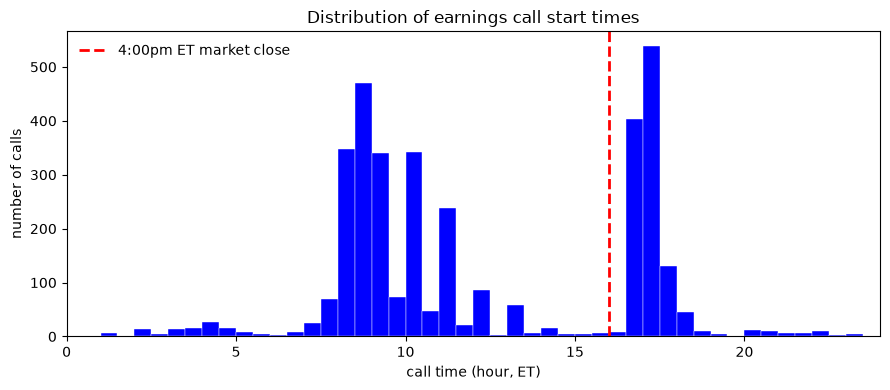

In [53]:
fig, ax = plt.subplots(figsize=(9, 4))
hours = call_times.map(lambda t: t.hour + t.minute / 60)
ax.hist(hours, bins=48, range=(0, 24), color='blue', edgecolor='white', linewidth=0.3)
ax.axvline(16, color='red', linewidth=2, linestyle="--", label="4:00pm ET market close")
ax.set_xlabel("call time (hour, ET)")
ax.set_ylabel("number of calls")
ax.set_title("Distribution of earnings call start times")
ax.set_xlim(0, 24)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

Note that we will also be doing similar carrying-forward operations with weekends and holidays in our data processing pipeline, but we will deal with this in our real data processing.